# Загрузка данных 

In [1]:
# Импорт необходимых библиотек
from src.pdb.PDBFile import PDBFile
from tqdm import tqdm
from src.preprocessing.interpolation import resample_trajectory, resample_trajectory_cubic_spline
from src.preprocessing.curves import get_invariant_features
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import torch
import torch.nn.functional as F
import warnings
import os
from sklearn.model_selection import train_test_split
from src.utils.config_loader import project_config
warnings.filterwarnings('ignore')

In [2]:
# Загрузка данных
K = 2048
BACKBONE_POINTS = []
ATOM_TYPES = []
import os
zero_error_count = 0
for root, dirs, files in os.walk('data/new_dompdb/dompdb'):
    for file in tqdm(files):
        file_path = os.path.join(root, file)
        pdb_file = PDBFile(file_path)
        if len(pdb_file.atom_line) > 0:
            backbone_coords, backbone_types = pdb_file.get_backbone_cloud()
            BACKBONE_POINTS.append(backbone_coords)
            ATOM_TYPES.append(backbone_types)
        else: 
            zero_error_count += 1



100%|██████████████████████████████████| 119369/119369 [05:26<00:00, 365.41it/s]


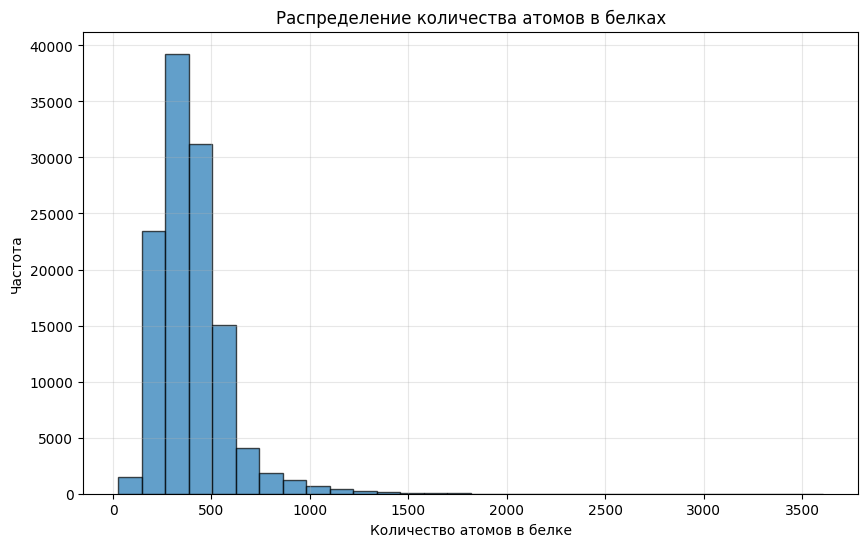

In [7]:
import numpy as np
import matplotlib.pyplot as plt
sizes = [len(protein) for protein in BACKBONE_POINTS]

plt.figure(figsize=(10, 6))
plt.hist(sizes, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Количество атомов в белке')
plt.ylabel('Частота')
plt.title('Распределение количества атомов в белках')
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
count = 0
for i in sizes:
    if i > 1500:
        count += 1
count

161

In [5]:
MIN_POINTS_FOR_SPLINE = 4
N_RESAMPLED_POINTS = 1024
AXIS_COORDINATES = 1
MASK_TRUE_VALUE = 1
MAX_THRESHOLD = 775 

In [6]:
resampled_atom_types = []
resampled_coords = []
failed_indices = []
for idx, example in enumerate(tqdm(BACKBONE_POINTS)):
    try:
        invariant_features = get_invariant_features(np.array(example))
        
        if len(invariant_features) > MAX_THRESHOLD:
            failed_indices.append((idx, f"Превышение порога: {len(invariant_features)} > {MAX_THRESHOLD}"))
            continue
        
        if len(invariant_features) < MIN_POINTS_FOR_SPLINE:
            print(f"Пример {idx}: недостаточно точек ({len(invariant_features)}) для сплайна, пропускаем")
            failed_indices.append((idx, "Недостаточно точек"))
            continue
            
        resampled = resample_trajectory_cubic_spline(invariant_features, k=N_RESAMPLED_POINTS)
        
        if resampled is not None and len(resampled) == N_RESAMPLED_POINTS:
            resampled_coords.append(resampled)
            
            mask = np.zeros(N_RESAMPLED_POINTS, dtype=np.int32)
            
            if idx < len(ATOM_TYPES) and len(ATOM_TYPES[idx]) == len(invariant_features):
                for index, orig_point in enumerate(invariant_features):
                    distances = np.linalg.norm(resampled - orig_point, axis=AXIS_COORDINATES)
                    closest_idx = np.argmin(distances)
                    mask[closest_idx] = ATOM_TYPES[idx][index] + 1
            else:
                print(f"Пример {idx}: несоответствие длины ATOM_TYPES и invariant_features")
                failed_indices.append((idx, "Несоответствие длины ATOM_TYPES"))
                continue
                
            resampled_atom_types.append(mask)  
        else:
            print(f"Пример {idx}: некорректный результат ресемплирования")
            failed_indices.append((idx, "Некорректный результат"))
            
    except ValueError as e:
        print(f"Пример {idx}: ValueError - {e}")
        failed_indices.append((idx, f"ValueError: {e}"))
    except Exception as e:
        print(f"Пример {idx}: неожиданная ошибка - {type(e).__name__}: {e}")
        failed_indices.append((idx, f"{type(e).__name__}: {e}"))

 72%|██████████████████████████          | 86434/119369 [21:57<07:17, 75.31it/s]

Пример 86425: ValueError - x_i должны быть строго возрастающими


100%|███████████████████████████████████| 119369/119369 [30:18<00:00, 65.64it/s]


In [9]:
resampled_atom_types[0]

array([2, 0, 0, ..., 0, 0, 3], shape=(1024,), dtype=int32)

In [10]:
resampled_coords[0]

array([[-30.78645033,   7.61059992,  -6.06066369],
       [-30.26112406,   7.3293575 ,  -6.31281287],
       [-29.84322354,   6.98253432,  -6.45859825],
       ...,
       [  4.98636078,   5.49279251, -12.77146198],
       [  5.3874978 ,   5.28254259, -13.11788559],
       [  5.93152539,   5.16238552, -13.49763843]], shape=(1024, 3))

In [131]:
import torch
from torch.utils.data import Dataset
import numpy as np

class VAETrajectoriesDataset(Dataset):
    def __init__(self, trajectories, atom_types, normalize=False):
        if isinstance(trajectories[0], torch.Tensor):
            self.dataset = torch.stack(trajectories)
        else:
            self.dataset = torch.tensor(np.array(trajectories), dtype=torch.float32)
        
        # Загружаем типы атомов
        if isinstance(atom_types[0], torch.Tensor):
            self.atom_types = torch.stack(atom_types)
        else:
            self.atom_types = torch.tensor(np.array(atom_types), dtype=torch.long)
        
        self.normalize = normalize
        
        # Вычисляем глобальные минимумы и максимумы для нормализации
        if self.normalize:
            self.global_min = self.dataset.min()
            self.global_max = self.dataset.max()
            
            # Нормализация всего датасета в диапазон [-1, 1]
            self.dataset = 2 * (self.dataset - self.global_min) / (self.global_max - self.global_min) - 1

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        trajectory = self.dataset[idx]  
        atom_type = self.atom_types[idx]
        
        one_hot = torch.zeros((trajectory.shape[0], 1), dtype=torch.float32)  # (1024, 3)
        
        one_hot[:, 0] = ((atom_type == 1) | (atom_type == 2) | (atom_type == 3)).float()   
        
        combined = torch.cat([trajectory, one_hot], dim=1)
        
        combined = combined.permute(1, 0)  
        return combined
    
    def denormalize(self, normalized_data):
        if not self.normalize:
            return normalized_data
        
        return (normalized_data + 1) / 2 * (self.global_max - self.global_min) + self.global_min

In [132]:
config = project_config.load()  

train_data_raw, val_data_raw, train_atom_types, val_atom_types = train_test_split(
    resampled_coords,resampled_atom_types,      
    test_size=config.get('training', {}).get('validation_split', 0.1),  
    random_state=42 
)

In [133]:
train_dataset = VAETrajectoriesDataset(
    trajectories=train_data_raw,
    atom_types=train_atom_types,
    normalize=True
)

val_dataset = VAETrajectoriesDataset(
    trajectories=val_data_raw,
    atom_types=val_atom_types,
    normalize=True
)


In [175]:
train_dataset[2].shape

torch.Size([4, 1024])

In [17]:
batch_size = 16
learning_rate = 0.0001
device = 'cuda'z

In [152]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False) 

In [196]:
model = ImprovedConv1DVAE(sequence_length = 1024)
model(train_dataset[0][:3].unsqueeze(0))[0].shape

torch.Size([1, 3, 1024])

In [323]:
class SeqEncoderLearnablePos(nn.Module):
    def __init__(self, input_length, encoding_dim=64, d_model=2):
        super().__init__()
        self.input_length = input_length
        
        self.value_embedding = nn.Embedding(2, d_model)
        
        self.pos_embedding = nn.Parameter(torch.randn(1, input_length, d_model))
        
        self.encoder = nn.Sequential(
            nn.Linear(d_model * input_length, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, encoding_dim)
        )
        
    def forward(self, x):
        batch_size = x.shape[0]
        
        x = self.value_embedding(x.long()) 
        
        x = x + self.pos_embedding
        
        x = x.reshape(batch_size, -1)
        
        encoded = self.encoder(x)
        return encoded

In [324]:
encoder = SeqEncoderLearnablePos(input_length = 1024, encoding_dim = 1024)
encoder(train_dataset[0][3:])

tensor([[-0.2028, -0.0470,  0.1304,  ...,  0.1028,  0.0125,  0.1282]],
       grad_fn=<AddmmBackward0>)

In [451]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(channels)
        self.activation = nn.LeakyReLU(0.2)
        
    def forward(self, x):
        residual = x
        out = self.activation(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        out = self.activation(out)
        return out


class ImprovedConv1DVAE(nn.Module):
    def __init__(self, latent_dim=128, input_channels=3, sequence_length=2048):
        super().__init__()
        
        self.latent_dim = latent_dim
        
        self.encoder = nn.Sequential(
            nn.Conv1d(input_channels, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            
            ResidualBlock(32),
            
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            
            ResidualBlock(64),
            
            nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            
            ResidualBlock(128),
            
            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            
            ResidualBlock(256),
            
            nn.Conv1d(256, 512, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            
            ResidualBlock(512),
            
            nn.AdaptiveAvgPool1d(16)  
        )
        
        self.fc_mu = nn.Linear(512 * 16, latent_dim)
        self.fc_logvar = nn.Linear(512 * 16, latent_dim)
        
        self.fc_decode = nn.Linear(latent_dim, 512 * 16)
        
        self.decoder = nn.Sequential(
            nn.Conv1d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            
            ResidualBlock(512),
            
            nn.Upsample(scale_factor=2, mode='linear'),  
            nn.Conv1d(512, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            
            ResidualBlock(256),
            
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            
            nn.Upsample(scale_factor=2, mode='linear'),  
            nn.Conv1d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            
            ResidualBlock(128),
            
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            
            nn.Upsample(scale_factor=2, mode='linear'),  
            nn.Conv1d(128, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            
            ResidualBlock(64),
            
            nn.Upsample(scale_factor=2, mode='linear'), 
            nn.Conv1d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.2),
            
            ResidualBlock(32),
            
            nn.Upsample(scale_factor=2, mode='linear'), 
            nn.Conv1d(32, 16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.LeakyReLU(0.2),
            
            ResidualBlock(16),
            
            nn.Upsample(scale_factor=4, mode='linear'),  
            nn.Conv1d(16, input_channels, kernel_size=3, padding=1),
            nn.Sigmoid()  
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1) 
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(h.size(0), 512, 16)  
        return self.decoder(h) 

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


In [452]:
model = ImprovedConv1DVAE(latent_dim = 256)
decode, mu, logvar = model(train_dataset[0].unsqueeze(0))

RuntimeError: Given groups=1, weight of size [32, 3, 7], expected input[1, 4, 1024] to have 3 channels, but got 4 channels instead

In [450]:
decode.shape

torch.Size([1, 3, 2048])

In [442]:
def vae_loss(recon_x, x, mu, logvar, beta=0.01, label_weight=1.0):
    recon_coords = recon_x[:, :3, :]
    recon_labels = recon_x[:, 3, :].squeeze(1)  # [batch, seq_len]
    
    x_coords = x[:, :3, :]
    x_labels = x[:, 3, :]  # [batch, seq_len]
    
    # MSE для координат
    coord_loss = F.mse_loss(recon_coords, x_coords, reduction='mean')
    
    # BCE для меток
    label_loss = F.binary_cross_entropy(recon_labels, x_labels, reduction='mean')
    
    # KL дивергенция
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    
    # Взвешенная сумма
    total_loss = coord_loss + label_weight * label_loss + beta * kl_loss
    
    return total_loss, coord_loss, label_loss, kl_loss


In [445]:
def train_vae(model, train_loader, val_loader=None, epochs=100, lr=1e-3, device='cuda'):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10)
    
    # Для логирования
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        train_coord_loss = 0
        train_label_loss = 0
        train_kl_loss = 0
        
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        for batch in progress_bar:
            batch = batch.to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            recon, mu, logvar = model(batch)
            
            # Вычисляем loss
            loss, coord_loss, label_loss, kl_loss = vae_loss(
                recon, batch, mu, logvar, 
                beta=min(1.0, epoch/10),  # Annealing for KL
                label_weight=2.0  # Увеличиваем вес для меток
            )
            
            # Backward pass
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            # Обновляем статистику
            train_loss += loss.item()
            train_coord_loss += coord_loss.item()
            train_label_loss += label_loss.item()
            train_kl_loss += kl_loss.item()
            
            # Обновляем progress bar
            progress_bar.set_postfix({
                'loss': loss.item(),
                'coord': coord_loss.item(),
                'label': label_loss.item(),
                'kl': kl_loss.item()
            })
        
        # Усредняем
        train_loss /= len(train_loader)
        train_coord_loss /= len(train_loader)
        train_label_loss /= len(train_loader)
        train_kl_loss /= len(train_loader)
        
        train_losses.append(train_loss)
        
        # Validation
        if val_loader:
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for batch in val_loader:
                    batch = batch.to(device)
                    recon, mu, logvar = model(batch)
                    loss, _, _, _ = vae_loss(recon, batch, mu, logvar)
                    val_loss += loss.item()
            
            val_loss /= len(val_loader)
            val_losses.append(val_loss)
            scheduler.step(val_loss)
            
            print(f'Epoch {epoch+1}: Train Loss: {train_loss:.4f} '
                  f'(Coord: {train_coord_loss:.4f}, Label: {train_label_loss:.4f}, KL: {train_kl_loss:.4f}) '
                  f'Val Loss: {val_loss:.4f}')
        else:
            scheduler.step(train_loss)
            print(f'Epoch {epoch+1}: Train Loss: {train_loss:.4f} '
                  f'(Coord: {train_coord_loss:.4f}, Label: {train_label_loss:.4f}, KL: {train_kl_loss:.4f})')
    
    return train_losses, val_losses


In [446]:
train_vae(model, train_loader, val_loader)

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
